In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the primary transaction dataset
df = pd.read_csv('../data/raw/data.csv')

In [6]:
# 1. Overview of the Data [3]
print("Dataset Shape:", df.shape)
print(df.info())
print(df.head())

Dataset Shape: (95662, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64

In [7]:
# 2. Summary Statistics [3]
# Analyzes central tendency, dispersion, and shape [3]
print(df.describe())

       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000


c:\Users\ELU\Desktop\credit-risk-model\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


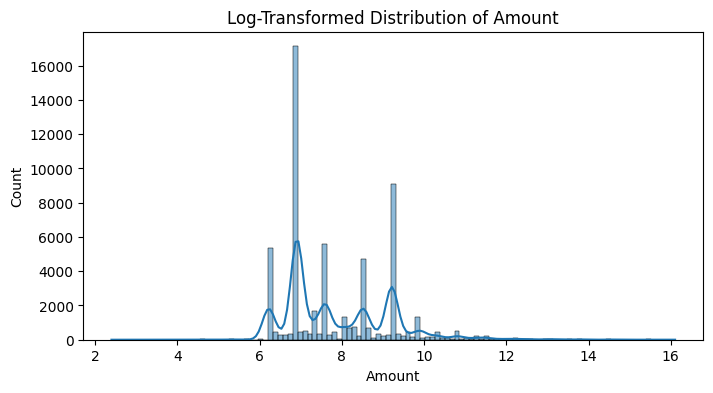

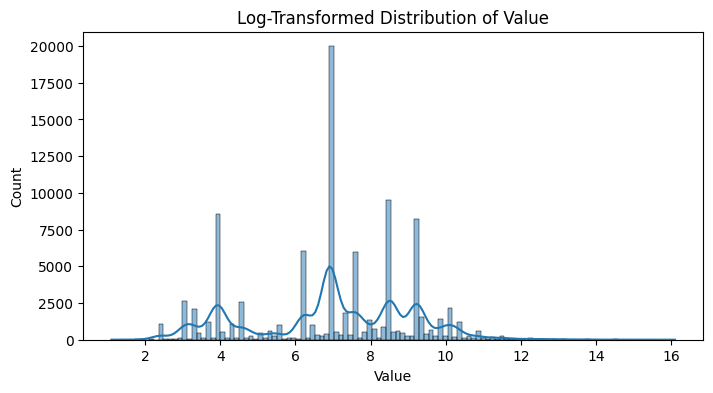

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['Amount', 'Value']
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    # log1p adds 1 before taking the log, handling zeros safely
    sns.histplot(np.log1p(df[col]), kde=True) 
    plt.title(f'Log-Transformed Distribution of {col}')
    plt.show()

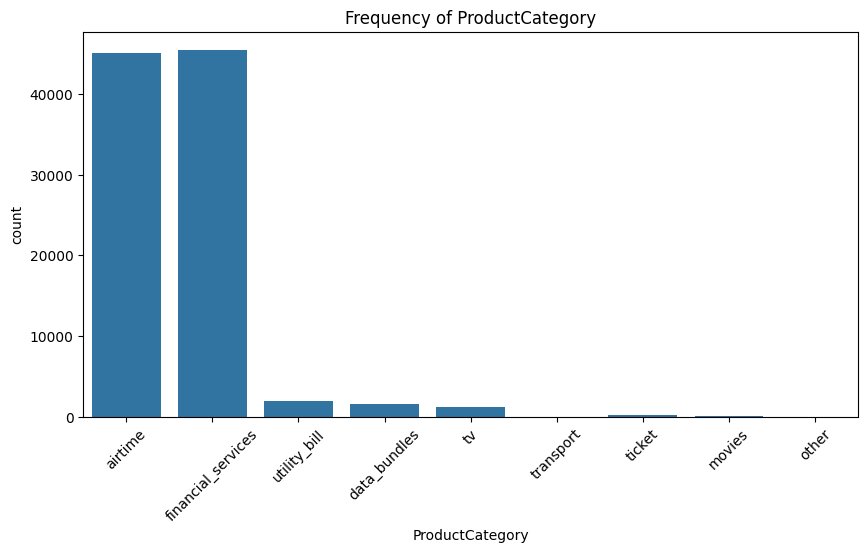

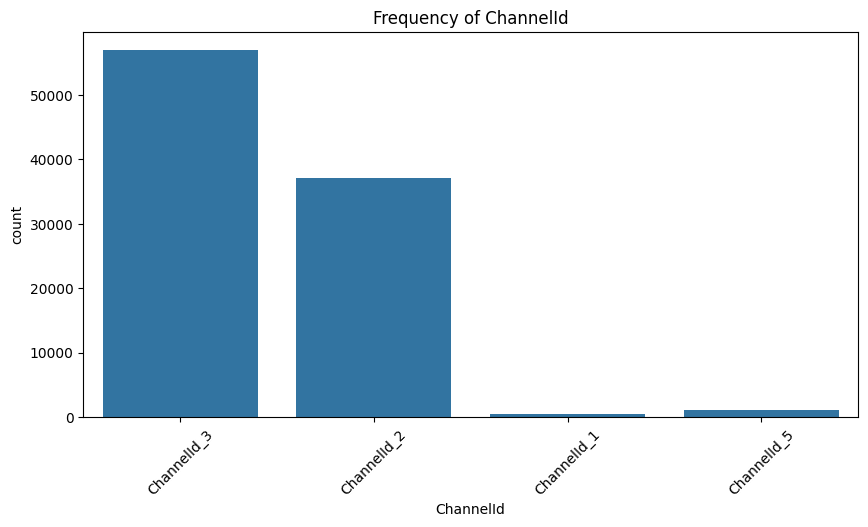

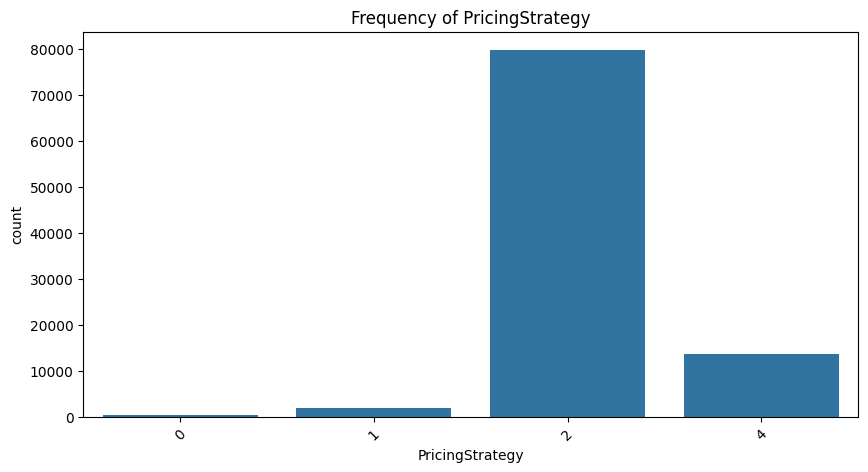

In [10]:
# 4. Distribution of Categorical Features [3]
# Analyzes frequency and variability [3]
categorical_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy']
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Frequency of {col}')
    plt.show()

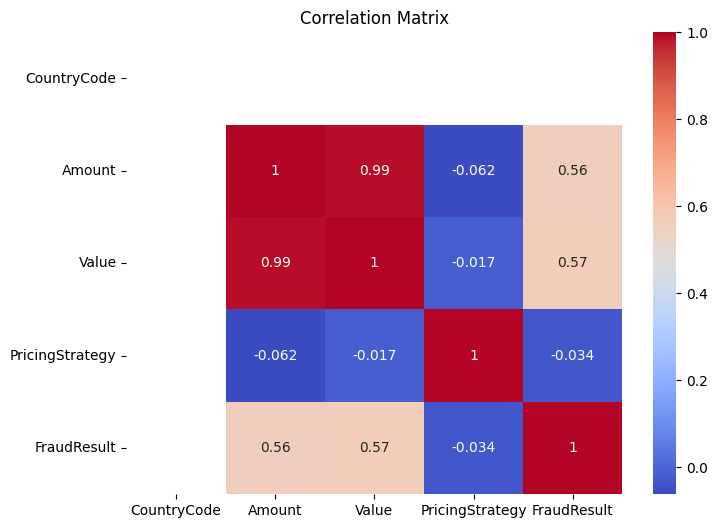

In [11]:
# 5. Correlation Analysis [2, 4]
# Detects multicollinearity between numerical features [4]
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Missing Values:
 TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64


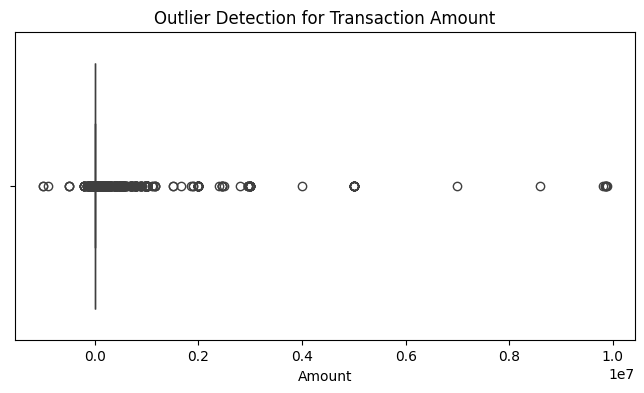

In [12]:
# 6. Identifying Missing Values and Outliers [2, 4]
print("Missing Values:\n", df.isnull().sum())

# Box plots to identify extreme outliers [2, 4]
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Amount'])
plt.title('Outlier Detection for Transaction Amount')
plt.show()

In [7]:
import pandas as pd
df = pd.read_csv('../data/raw/data.csv')
print(df.columns.tolist())

['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


In [6]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\ELU\Desktop\credit-risk-model\notebooks


In [3]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Now you can import from src
from src.data_processing import get_full_pipeline